# Tiny Shakespeare Dataset - Attention

### [Tiny Shakespeare Dataset](https://github.com/karpathy/char-rnn)

Author: [Kevin Thomas](mailto:ket189@pitt.edu)

License: MIT

## Citation

[1] Andrej Karpathy, https://github.com/karpathy/char-rnn

[2] Ashish Vaswani et al., https://arxiv.org/abs/1706.03762

## Install Libraries

In [1]:
# conda activate prod
# conda install -c conda-forge pytorch torchvision torchaudio
# conda install numpy matplotlib

## Import Libraries

In [2]:
import urllib.request
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
%matplotlib inline

## Seed

In [3]:
SEED = 42
SEED

42

In [4]:
torch.manual_seed(SEED)

## Parameters

In [5]:
SEQ_LEN = 64
SEQ_LEN

64

In [6]:
EMBED_DIM = 64
EMBED_DIM

64

In [7]:
N_HEADS = 4
N_HEADS

4

In [8]:
FF_DIM = 128
FF_DIM

128

## Hyperparameters

In [9]:
LEARNING_RATE = 0.002
LEARNING_RATE

0.002

In [10]:
EPOCHS = 10
EPOCHS

10

In [11]:
BATCH_SIZE = 128
BATCH_SIZE

128

## Device

In [12]:
DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu")
DEVICE

device(type='mps')

## Download Dataset

In [13]:
URL = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
urllib.request.urlretrieve(URL, 'data/tinyshakespeare.txt')
with open('data/tinyshakespeare.txt', encoding='utf-8') as handle:
    text = handle.read()
print('length:', len(text))

length: 1115394


## Build Vocabulary

In [14]:
CHARS = sorted(set(text))
STOI = {ch: i for i, ch in enumerate(CHARS)}
ITOS = {i: ch for i, ch in enumerate(CHARS)}
VOCAB_SIZE = len(CHARS)
data = torch.tensor([STOI[ch] for ch in text], dtype=torch.long)
print('vocab size:', VOCAB_SIZE)

vocab size: 65


## Attention From Scratch

Attention lets every position look at every other position. The scores are the dot products of queries and keys, scaled by the square root of the key dimension, then turned into weights with softmax.

### Scaled Dot-Product Attention

In [15]:
def scaled_dot_product_attention(query, key, value, mask=None):
    """
    Compute scaled dot-product attention.

    Parameters:
        query (torch.Tensor): Query tensor.
        key (torch.Tensor): Key tensor.
        value (torch.Tensor): Value tensor.
        mask (torch.Tensor): Optional mask of allowed positions.

    Returns:
        tuple: Attention output and attention weights.
    """
    d_k = query.size(-1)
    scores = query @ key.transpose(-2, -1) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))
    weights = torch.softmax(scores, dim=-1)
    return weights @ value, weights

### Try It on a Small Sequence

In [16]:
torch.manual_seed(SEED)
tokens = torch.randn(5, 8)
out, weights = scaled_dot_product_attention(tokens, tokens, tokens)
print('output shape:', out.shape)
print('weight row sums:', weights.sum(dim=-1))

output shape: torch.Size([5, 8])
weight row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


### Causal Mask

A language model may not look at future characters. A causal mask blocks every position from attending to later positions.

In [17]:
def causal_mask(size):
    """
    Build a lower-triangular causal mask.

    Parameters:
        size (int): Sequence length.

    Returns:
        torch.Tensor: A size x size mask.
    """
    return torch.tril(torch.ones(size, size)).bool()

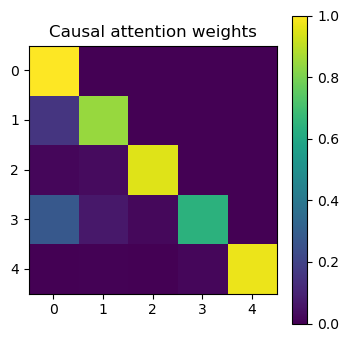

In [18]:
torch.manual_seed(SEED)
tokens = torch.randn(5, 8)
mask = causal_mask(5)
out, weights = scaled_dot_product_attention(tokens, tokens, tokens, mask)
plt.figure(figsize=(4, 4))
plt.imshow(weights.detach(), cmap='viridis')
plt.title('Causal attention weights')
plt.colorbar()
plt.show()

## Multi-Head Attention

In [19]:
class MultiHeadAttention(nn.Module):
    """
    Multi-head self-attention with a causal mask.
    """

    def __init__(self, embed_dim, n_heads):
        """
        Initialize the query, key, value, and output projections.

        Parameters:
            embed_dim (int): Embedding size.
            n_heads (int): Number of attention heads.

        Returns:
            None
        """
        super(MultiHeadAttention, self).__init__()
        self.n_heads = n_heads
        self.head_dim = embed_dim // n_heads
        self.qkv = nn.Linear(embed_dim, 3 * embed_dim)
        self.proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        """
        Run multi-head causal self-attention.

        Parameters:
            x (torch.Tensor): Input of shape (batch, time, embed_dim).

        Returns:
            torch.Tensor: Attention output.
        """
        batch, time, embed_dim = x.shape
        qkv = self.qkv(x).reshape(batch, time, 3, self.n_heads, self.head_dim)
        query, key, value = qkv.permute(2, 0, 3, 1, 4)
        out = F.scaled_dot_product_attention(query, key, value, is_causal=True)
        out = out.transpose(1, 2).reshape(batch, time, embed_dim)
        return self.proj(out)

## Transformer Block

In [20]:
class TransformerBlock(nn.Module):
    """
    A single transformer block with attention and a feed-forward network.
    """

    def __init__(self, embed_dim, n_heads, ff_dim):
        """
        Initialize attention, normalization, and feed-forward layers.

        Parameters:
            embed_dim (int): Embedding size.
            n_heads (int): Number of attention heads.
            ff_dim (int): Feed-forward hidden size.

        Returns:
            None
        """
        super(TransformerBlock, self).__init__()
        self.attn = MultiHeadAttention(embed_dim, n_heads)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Linear(ff_dim, embed_dim))
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        """
        Run the block with residual connections.

        Parameters:
            x (torch.Tensor): Input of shape (batch, time, embed_dim).

        Returns:
            torch.Tensor: Output of the same shape.
        """
        x = self.norm1(x + self.attn(x))
        return self.norm2(x + self.ff(x))

## Create Model

In [21]:
class AttentionModel(nn.Module):
    """
    A character language model with one transformer block.
    """

    def __init__(self, vocab_size, embed_dim, n_heads, ff_dim, max_len):
        """
        Initialize embeddings, the transformer block, and the output head.

        Parameters:
            vocab_size (int): Number of characters.
            embed_dim (int): Embedding size.
            n_heads (int): Number of attention heads.
            ff_dim (int): Feed-forward hidden size.
            max_len (int): Maximum sequence length.

        Returns:
            None
        """
        super(AttentionModel, self).__init__()
        self.token_embed = nn.Embedding(vocab_size, embed_dim)
        self.pos_embed = nn.Embedding(max_len, embed_dim)
        self.block = TransformerBlock(embed_dim, n_heads, ff_dim)
        self.head = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        """
        Run the forward pass of the model.

        Parameters:
            x (torch.Tensor): Input index batch.

        Returns:
            torch.Tensor: Output logits.
        """
        positions = torch.arange(x.size(1), device=x.device)
        x = self.token_embed(x) + self.pos_embed(positions)
        x = self.block(x)
        return self.head(x)

## Create Dataset and DataLoader

In [22]:
class CharDataset(torch.utils.data.Dataset):
    """
    A dataset of fixed-length character windows and next-character targets.
    """

    def __init__(self, data, seq_len):
        """
        Store the encoded text and window length.

        Parameters:
            data (torch.Tensor): Encoded text.
            seq_len (int): Length of each input window.

        Returns:
            None
        """
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        """
        Return the number of windows.

        Parameters:
            None

        Returns:
            int: Number of windows.
        """
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        """
        Return one input window and its shifted target.

        Parameters:
            idx (int): Window index.

        Returns:
            tuple: Input and target tensors.
        """
        x = self.data[idx:idx + self.seq_len]
        y = self.data[idx + 1:idx + self.seq_len + 1]
        return x, y

In [23]:
split = int(0.9 * len(data))
train_data = CharDataset(data[:split], SEQ_LEN)
val_data = CharDataset(data[split:], SEQ_LEN)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
len(train_loader), len(val_loader)

(7843, 871)

## Instantiate Model, Loss, and Optimizer

In [24]:
torch.manual_seed(SEED)
model = AttentionModel(VOCAB_SIZE, EMBED_DIM, N_HEADS, FF_DIM, SEQ_LEN).to(DEVICE)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
model

AttentionModel(
  (token_embed): Embedding(65, 64)
  (pos_embed): Embedding(64, 64)
  (block): TransformerBlock(
    (attn): MultiHeadAttention(
      (qkv): Linear(in_features=64, out_features=192, bias=True)
      (proj): Linear(in_features=64, out_features=64, bias=True)
    )
    (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (ff): Sequential(
      (0): Linear(in_features=64, out_features=128, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=128, out_features=64, bias=True)
    )
    (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (head): Linear(in_features=64, out_features=65, bias=True)
)

## Train Model

### Functions

In [25]:
def train_epoch(model, loader, loss_fn, optimizer):
    """
    Train the model for a single epoch.

    Parameters:
        model (nn.Module): The model to train.
        loader (DataLoader): Training data loader.
        loss_fn (nn.Module): Loss function.
        optimizer (torch.optim.Optimizer): Parameter update rule.

    Returns:
        float: Mean training loss.
    """
    model.train()
    total = 0.0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits.transpose(1, 2), y)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(y)
    return total / len(loader.dataset)


def evaluate(model, loader, loss_fn):
    """
    Evaluate the model over a loader.

    Parameters:
        model (nn.Module): The model to evaluate.
        loader (DataLoader): Evaluation data loader.
        loss_fn (nn.Module): Loss function.

    Returns:
        float: Mean loss.
    """
    model.eval()
    total = 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            total += loss_fn(logits.transpose(1, 2), y).item() * len(y)
    return total / len(loader.dataset)

### Training Loop

In [26]:
history = []
for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, loss_fn, optimizer)
    val_loss = evaluate(model, val_loader, loss_fn)
    history.append(val_loss)
    print(f"Epoch {epoch + 1:2d} | train loss {train_loss:.4f} | val loss {val_loss:.4f}")

Epoch  1 | train loss 1.7006 | val loss 1.7970


Epoch  2 | train loss 1.5685 | val loss 1.7978


Epoch  3 | train loss 1.5497 | val loss 1.7935


Epoch  4 | train loss 1.5396 | val loss 1.7926


Epoch  5 | train loss 1.5329 | val loss 1.7907


Epoch  6 | train loss 1.5280 | val loss 1.7828


Epoch  7 | train loss 1.5243 | val loss 1.7718


Epoch  8 | train loss 1.5214 | val loss 1.7763


Epoch  9 | train loss 1.5190 | val loss 1.7782


Epoch 10 | train loss 1.5171 | val loss 1.7821


### Visualize Training

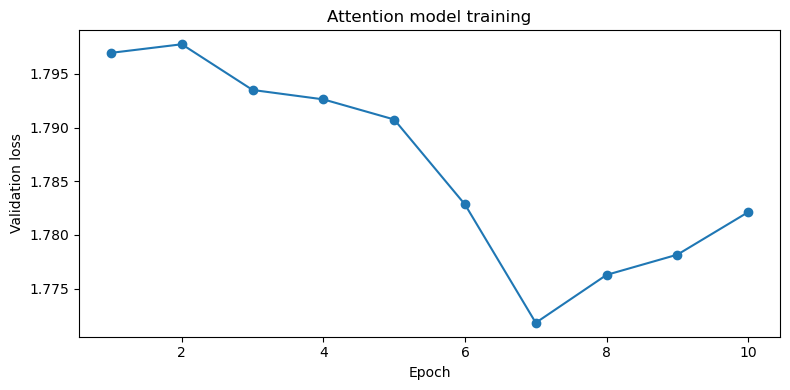

In [27]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), history, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Validation loss')
plt.title('Attention model training')
plt.tight_layout()
plt.show()

## Generate Text

In [28]:
def generate(model, start, length, temperature=0.8):
    """
    Generate text from a trained model.

    Parameters:
        model (nn.Module): Trained model.
        start (str): Seed text.
        length (int): Number of characters to generate.
        temperature (float): Sampling temperature.

    Returns:
        str: The generated text.
    """
    model.eval()
    indices = [STOI[ch] for ch in start]
    with torch.no_grad():
        for _ in range(length):
            window = torch.tensor(indices[-SEQ_LEN:]).unsqueeze(0).to(DEVICE)
            logits = model(window)
            probs = torch.softmax(logits[0, -1] / temperature, dim=0)
            indices.append(torch.multinomial(probs, 1).item())
    return ''.join(ITOS[i] for i in indices)

In [29]:
print(generate(model, 'ROMEO: ', 300))

ROMEO: he say souls.

Second God's no loss hater, that the power:
Farewell, that his Clarence, and, First Coriolanus
To the cousiness mine else thee laster his yourself,
And me; the entern that like in that wing hence as there peace merry such stay here and yet things of like a should sicks were test then 


## Save Model

In [30]:
torch.save(model.state_dict(), 'models/attention_shakespeare.pt')
print('saved attention_shakespeare.pt')

saved attention_shakespeare.pt


## Load Model

In [31]:
loaded_model = AttentionModel(VOCAB_SIZE, EMBED_DIM, N_HEADS, FF_DIM, SEQ_LEN).to(DEVICE)
loaded_model.load_state_dict(torch.load('models/attention_shakespeare.pt', map_location=DEVICE))
loaded_model.eval()
print('loaded attention_shakespeare.pt')

loaded attention_shakespeare.pt


/var/folders/qg/60m3b34x32gczgr10l3665300000gn/T/ipykernel_77185/746794393.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load('model

## Inference

In [32]:
print(generate(loaded_model, 'JULIET: ', 200))

JULIET: to all leave worst that the be mother prove die the part
And bests dead sweet loes in a proported enemia redit was with the sorrow,
My shall scopt that was no news in nothings.

LADY GREY:
Most I do I
